In [ ]:
# =============================================================
# CELL 1 — Install dependencies
# =============================================================
!pip install -q torch torchvision opencv-python matplotlib tqdm pandas pycocotools
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

  Preparing metadata (setup.py) ... done


In [ ]:
# =============================================================
# CELL 2 — Imports
# =============================================================
import os
import cv2
import time
import torch
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import torchvision
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.data import Dataset, DataLoader

from segment_anything import sam_model_registry, SamPredictor

In [ ]:
# =============================================================
# CELL 3 — Paths + extract dataset
# =============================================================
zip_path = "/content/TILDA Fabric.v1-final.yolov8 (2).zip"

raw_dataset = Path("/content/tilda_raw")
dataset_dir = Path("/content/tilda_maskrcnn")

for p in [raw_dataset, dataset_dir]:
    if p.exists():
        shutil.rmtree(p)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(raw_dataset)

shutil.copytree(raw_dataset, dataset_dir)

for split in ["train", "valid", "test"]:
    print(split, "images:", len(list((dataset_dir / split / "images").glob("*"))))

train images: 280
valid images: 80
test images: 40


In [ ]:
# =============================================================
# CELL 4 — Preprocessing: CLAHE (LAB) + Bilateral Filter
# =============================================================
def apply_clahe_bilateral(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    clahe_image = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    return cv2.bilateralFilter(clahe_image, d=9, sigmaColor=75, sigmaSpace=75)


for split in ["train", "valid", "test"]:
    image_dir = dataset_dir / split / "images"
    for image_path in tqdm(list(image_dir.glob("*")), desc=f"Preprocessing {split}"):
        image = cv2.imread(str(image_path))
        if image is None:
            continue
        cv2.imwrite(str(image_path), apply_clahe_bilateral(image))

print("Preprocessing completed")


Preprocessing test: 100%|██████████| 40/40 [00:03<00:00, 12.75it/s]

Preprocessing completed


In [ ]:
# =============================================================
# CELL 5 — Download SAM checkpoint and load model
# =============================================================
!wget -q -O /content/sam_vit_h_4b8939.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sam = sam_model_registry["vit_h"](checkpoint="/content/sam_vit_h_4b8939.pth")
sam.to(device)
predictor = SamPredictor(sam)

print("SAM loaded on:", device)

SAM loaded on: cuda


In [ ]:
# =============================================================
# CELL 6 — Generate SAM polygon masks (saved as .npy mask files)
# =============================================================
mask_root = dataset_dir  # masks saved alongside images in a "masks" folder per split

def yolo_bbox_to_xyxy(values, img_w, img_h):
    class_id, x, y, w, h = values
    x *= img_w;  y *= img_h
    w *= img_w;  h *= img_h
    x1 = max(0, x - w / 2)
    y1 = max(0, y - h / 2)
    x2 = min(img_w - 1, x + w / 2)
    y2 = min(img_h - 1, y + h / 2)
    return int(class_id), np.array([x1, y1, x2, y2])


def generate_sam_masks(split):
    image_dir = dataset_dir / split / "images"
    label_dir = dataset_dir / split / "labels"
    mask_dir  = dataset_dir / split / "masks"
    mask_dir.mkdir(parents=True, exist_ok=True)

    image_paths = (
        list(image_dir.glob("*.jpg")) +
        list(image_dir.glob("*.jpeg")) +
        list(image_dir.glob("*.png"))
    )

    for image_path in tqdm(image_paths, desc=f"SAM masks {split}"):
        label_path = label_dir / f"{image_path.stem}.txt"
        if not label_path.exists():
            continue

        image = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_h, img_w = image.shape[:2]
        predictor.set_image(image_rgb)

        masks_list, labels_list, boxes_list = [], [], []

        for line in label_path.read_text().strip().splitlines():
            values = list(map(float, line.split()))
            if len(values) < 5:
                continue

            if len(values) == 5:
                class_id, box = yolo_bbox_to_xyxy(values, img_w, img_h)
            else:
                class_id = int(values[0])
                coords = values[1:]
                xs = [coords[i] * img_w for i in range(0, len(coords), 2)]
                ys = [coords[i] * img_h for i in range(1, len(coords), 2)]
                box = np.array([min(xs), min(ys), max(xs), max(ys)])

            masks, scores, _ = predictor.predict(box=box, multimask_output=True)
            best_mask = masks[np.argmax(scores)]

            ys_m, xs_m = np.where(best_mask)
            if len(xs_m) == 0:
                continue

            masks_list.append(best_mask.astype(np.uint8))
            labels_list.append(class_id + 1)  # +1 for background
            boxes_list.append([xs_m.min(), ys_m.min(), xs_m.max(), ys_m.max()])

        np.savez(
            mask_dir / f"{image_path.stem}.npz",
            masks=np.array(masks_list, dtype=np.uint8),
            labels=np.array(labels_list, dtype=np.int64),
            boxes=np.array(boxes_list, dtype=np.float32),
        )


for split in ["train", "valid", "test"]:
    generate_sam_masks(split)

print("SAM mask generation completed")


SAM masks test: 100%|██████████| 40/40 [01:24<00:00,  2.11s/it]

SAM mask generation completed


In [ ]:
# =============================================================
# CELL 7 — Augmentation (train only): hflip, vflip, rot180
# =============================================================
image_dir = dataset_dir / "train" / "images"
mask_dir  = dataset_dir / "train" / "masks"

original_images = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))

for image_path in tqdm(original_images, desc="Augmenting train"):
    mask_path = mask_dir / f"{image_path.stem}.npz"
    if not mask_path.exists():
        continue

    image = cv2.imread(str(image_path))
    data = np.load(mask_path)
    masks, labels, boxes = data["masks"], data["labels"], data["boxes"]

    if masks.shape[0] == 0:
        continue

    img_h, img_w = image.shape[:2]

    transforms = {
        "hflip":  (cv2.flip(image, 1), [m[:, ::-1] for m in masks]),
        "vflip":  (cv2.flip(image, 0), [m[::-1, :] for m in masks]),
        "rot180": (cv2.rotate(image, cv2.ROTATE_180), [m[::-1, ::-1] for m in masks]),
    }

    for aug_name, (aug_img, aug_masks) in transforms.items():
        aug_masks = np.array(aug_masks, dtype=np.uint8)

        # recompute boxes from flipped masks
        aug_boxes = []
        for m in aug_masks:
            ys_m, xs_m = np.where(m)
            aug_boxes.append([xs_m.min(), ys_m.min(), xs_m.max(), ys_m.max()])

        cv2.imwrite(str(image_dir / f"{image_path.stem}_{aug_name}.jpg"), aug_img)
        np.savez(
            mask_dir / f"{image_path.stem}_{aug_name}.npz",
            masks=aug_masks,
            labels=labels,
            boxes=np.array(aug_boxes, dtype=np.float32),
        )

print("Augmentation completed")
print("Final train images:", len(list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))))


Augmenting train: 100%|██████████| 280/280 [00:06<00:00, 41.18it/s]


Augmentation completed
Final train images: 1120


In [ ]:
# =============================================================
# CELL 8 — Dataset class
# =============================================================
class TILDAMaskDataset(Dataset):
    def __init__(self, root):
        self.image_dir = Path(root) / "images"
        self.mask_dir  = Path(root) / "masks"
        self.image_paths = [
            p for p in (list(self.image_dir.glob("*.jpg")) + list(self.image_dir.glob("*.png")))
            if (self.mask_dir / f"{p.stem}.npz").exists()
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_tensor = torchvision.transforms.functional.to_tensor(image)

        data = np.load(self.mask_dir / f"{image_path.stem}.npz")
        masks  = torch.as_tensor(data["masks"], dtype=torch.uint8)
        labels = torch.as_tensor(data["labels"], dtype=torch.int64)
        boxes  = torch.as_tensor(data["boxes"], dtype=torch.float32)

        if masks.shape[0] == 0:
            masks  = torch.zeros((0, image.shape[0], image.shape[1]), dtype=torch.uint8)
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx]),
        }
        return image_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = TILDAMaskDataset(dataset_dir / "train")
valid_dataset = TILDAMaskDataset(dataset_dir / "valid")
test_dataset  = TILDAMaskDataset(dataset_dir / "test")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, collate_fn=collate_fn)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test: ", len(test_dataset))

Train: 1120
Valid: 80
Test:  40


In [ ]:
# =============================================================
# CELL 9 — Load Mask R-CNN model
# =============================================================
num_classes = 5  # background + hole + objects + oil_spot + thread_error

model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT
)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

model.to(device)
print("Model loaded on:", device)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 185MB/s]


Model loaded on: cuda


In [ ]:
# =============================================================
# CELL 10 — Training (100 epochs, early stopping)
# =============================================================
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=0.0005
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

num_epochs = 100
patience   = 30
best_val_loss = float("inf")
counter = 0
train_losses, valid_losses = [], []

for epoch in range(num_epochs):
    # ---- train ----
    model.train()
    train_loss = 0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Train"):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        train_loss += losses.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ---- validation ----
    model.train()  # loss dict only available in train mode
    val_loss = 0
    with torch.no_grad():
        for images, targets in valid_loader:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            val_loss += sum(loss for loss in loss_dict.values()).item()

    val_loss /= len(valid_loader)
    valid_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

    # ---- early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "/content/best_maskrcnn_sam.pth")
    else:
        counter += 1
        print(f"No improvement for {counter} epochs")
        if counter >= patience:
            print("Early stopping")
            break

Epoch 1/100 Train: 100%|██████████| 560/560 [05:43<00:00,  1.63it/s]


Epoch 1: train_loss=0.6573 val_loss=0.5762


Epoch 2/100 Train: 100%|██████████| 560/560 [05:44<00:00,  1.63it/s]


Epoch 2: train_loss=0.4589 val_loss=0.5391


Epoch 3/100 Train: 100%|██████████| 560/560 [05:45<00:00,  1.62it/s]


...

Epoch 32: train_loss=0.0922 val_loss=0.6775
No improvement for 28 epochs


Epoch 33/100 Train: 100%|██████████| 560/560 [05:49<00:00,  1.60it/s]


Epoch 33: train_loss=0.0920 val_loss=0.6770
No improvement for 29 epochs


Epoch 34/100 Train: 100%|██████████| 560/560 [05:48<00:00,  1.60it/s]


Epoch 34: train_loss=0.0918 val_loss=0.6843
No improvement for 30 epochs
Early stopping


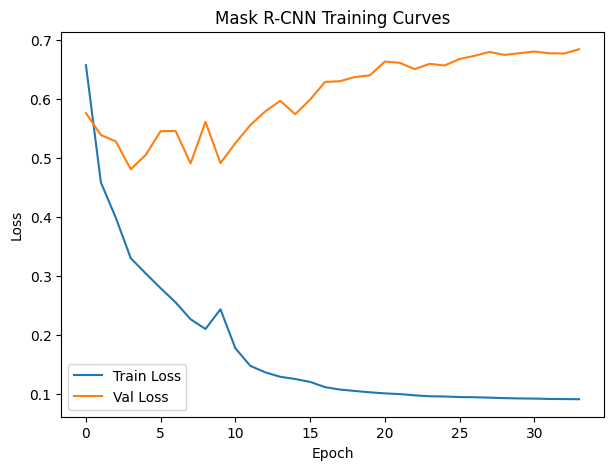

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.7 MB/s eta 0:00:00


Evaluating: 100%|██████████| 40/40 [00:06<00:00,  6.64it/s]


Box mAP50    : 0.5716702342033386
Box mAP50-95 : 0.3497213125228882
Mask mAP50   : 0.47058427333831787
Mask mAP50-95: 0.28841692209243774


FPS benchmark: 100%|██████████| 40/40 [00:05<00:00,  7.01it/s]

Average inference time: 130.86 ms
FPS: 7.64


In [ ]:

# =============================================================
# CELL 11 — Plot training curves
# =============================================================
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mask R-CNN Training Curves")
plt.legend()
plt.show()


# =============================================================
# CELL 12 — Evaluation: mAP (box + mask)
# =============================================================
!pip install -q torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

model.load_state_dict(torch.load("/content/best_maskrcnn_sam.pth"))
model.to(device)
model.eval()

box_metric  = MeanAveragePrecision(iou_type="bbox")
mask_metric = MeanAveragePrecision(iou_type="segm")

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating"):
        images = [img.to(device) for img in images]
        outputs = model(images)

        preds = []
        for out in outputs:
            preds.append({
                "boxes":  out["boxes"].cpu(),
                "scores": out["scores"].cpu(),
                "labels": out["labels"].cpu(),
                "masks":  (out["masks"] > 0.5).squeeze(1).cpu().to(torch.uint8),
            })

        gts = []
        for t in targets:
            gts.append({
                "boxes":  t["boxes"],
                "labels": t["labels"],
                "masks":  t["masks"].to(torch.uint8),
            })

        box_metric.update(preds, gts)
        mask_metric.update(preds, gts)

box_results  = box_metric.compute()
mask_results = mask_metric.compute()

print("Box mAP50    :", box_results["map_50"].item())
print("Box mAP50-95 :", box_results["map"].item())
print("Mask mAP50   :", mask_results["map_50"].item())
print("Mask mAP50-95:", mask_results["map"].item())


# =============================================================
# CELL 13 — FPS benchmark
# =============================================================
model.eval()
times = []

with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="FPS benchmark"):
        img = images[0].to(device)

        torch.cuda.synchronize() if device.type == "cuda" else None
        start = time.time()
        _ = model([img])
        torch.cuda.synchronize() if device.type == "cuda" else None
        times.append(time.time() - start)

avg_time = sum(times) / len(times)
print(f"Average inference time: {avg_time*1000:.2f} ms")
print(f"FPS: {1/avg_time:.2f}")